# Deduplicate to prevent data leakage

In [ ]:
import sys
!{sys.executable} -m pip install imagehash Pillow tqdm matplotlib pandas scikit-learn tensorflow

#### Settings

In [9]:
import os
from pathlib import Path


BASE_DIR    = Path(r"C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets")
DROWSY_DIR  = BASE_DIR / "Drowsy"
NDROWSY_DIR = BASE_DIR / "Non Drowsy"
OUTPUT_DIR  = BASE_DIR / "clean_dataset"
DUP_DIR     = BASE_DIR / "duplicates"


HASH_THRESHOLD = 8

TRAIN_RATIO = 0.80
TEST_RATIO  = 0.20
RANDOM_SEED = 42

print(f"   Drowsy    : {DROWSY_DIR}")
print(f"   Non Drowsy: {NDROWSY_DIR}")
print(f"   Duplicates: {DUP_DIR}")
print(f"   Clean out : {OUTPUT_DIR}")
print(f"   Threshold : Hamming ≤ {HASH_THRESHOLD}")

   Drowsy    : C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\Drowsy
   Non Drowsy: C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\Non Drowsy
   Duplicates: C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\duplicates
   Clean out : C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\clean_dataset
   Threshold : Hamming ≤ 8


#### Compute pHash for All Images

In [10]:
import imagehash
from PIL import Image
from tqdm import tqdm
import pandas as pd
from pathlib import Path

SUPPORTED = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

def get_all_images(folder: Path) -> list:
    return [p for p in folder.rglob('*') if p.suffix.lower() in SUPPORTED]

def compute_hashes(image_paths: list, label: str) -> pd.DataFrame:
    records = []
    errors = []

    for p in tqdm(image_paths, desc=f"Hashing [{label}]"):
        try:
            img = Image.open(p).convert('RGB')
            phash = imagehash.phash(img, hash_size=16)
            records.append({
                'path': str(p),
                'label': label,
                'phash': phash
            })
        except Exception as e:
            errors.append({'path': str(p), 'error': str(e)})

    if errors:
        print(f"{len(errors)} images could not be opened in [{label}]")

    return pd.DataFrame(records)


drowsy_imgs = get_all_images(DROWSY_DIR)
ndrowsy_imgs = get_all_images(NDROWSY_DIR)

print(f"\nDrowsy: {len(drowsy_imgs):,} images")
print(f"Non Drowsy: {len(ndrowsy_imgs):,} images")
print(f"Total: {len(drowsy_imgs) + len(ndrowsy_imgs):,} images")

df_drowsy = compute_hashes(drowsy_imgs, 'drowsy')
df_ndrowsy = compute_hashes(ndrowsy_imgs, 'non_drowsy')

df_all = pd.concat([df_drowsy, df_ndrowsy], ignore_index=True)

print(f"\nComputed hash for {len(df_all):,} images")


Drowsy: 22,348 images
Non Drowsy: 19,445 images
Total: 41,793 images


Hashing [non_drowsy]: 100%|██████████| 19445/19445 [00:30<00:00, 639.64it/s]


Computed hash for 41,793 images


#### Detect duplicates within each class and between classes

In [ ]:
from itertools import combinations
import numpy as np

def find_duplicates(df: pd.DataFrame, threshold: int) -> tuple:

    hashes = df['phash'].tolist()
    paths  = df['path'].tolist()
    labels = df['label'].tolist()
    n      = len(hashes)

    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        parent[find(a)] = find(b)

    dup_pairs = []
    cross_count = 0

    print("Comparing images... this may take time for large datasets.")

    for i in tqdm(range(n)):
        for j in range(i + 1, n):
            dist = hashes[i] - hashes[j]

            if dist <= threshold:
                union(i, j)

                pair_type = 'cross-class' if labels[i] != labels[j] else 'same-class'

                dup_pairs.append({
                    'path_a': paths[i],
                    'path_b': paths[j],
                    'distance': dist,
                    'label_a': labels[i],
                    'label_b': labels[j],
                    'type': pair_type
                })

                if pair_type == 'cross-class':
                    cross_count += 1

    groups = {}

    for idx in range(n):
        root = find(idx)
        groups.setdefault(root, []).append(idx)

    to_remove = set()

    for root, members in groups.items():
        if len(members) > 1:
            for m in members[1:]:
                to_remove.add(paths[m])

    return dup_pairs, to_remove, cross_count


dup_pairs, to_remove, cross_count = find_duplicates(df_all, HASH_THRESHOLD)

df_pairs = pd.DataFrame(dup_pairs)

print("\n" + "=" * 55)
print(f"Duplicate detection results (threshold = {HASH_THRESHOLD})")
print("=" * 55)

print(f"Total duplicate pairs: {len(dup_pairs):,}")

if len(df_pairs):
    same = (df_pairs['type'] == 'same-class').sum()
    cross = (df_pairs['type'] == 'cross-class').sum()

    print(f"Within same class: {same:,}")
    print(f"Between Drowsy & Non-Drowsy: {cross:,}")

print(f"Images marked for removal: {len(to_remove):,}")
print(f"Clean images remaining: {len(df_all) - len(to_remove):,}")

In [12]:
import pandas as pd
from tqdm import tqdm
from typing import Any, Dict, List, Tuple


def to_int_hash(value):
    """
    Convert different phash formats to a Python int.
    Supports:
    - imagehash.ImageHash
    - int / numpy integer
    - hex string
    """

    # imagehash.ImageHash usually has a .hash boolean array
    if hasattr(value, "hash"):
        bits = value.hash.flatten()
        out = 0
        for bit in bits:
            out = (out << 1) | int(bit)
        return out

    # plain integers / numpy integers
    if isinstance(value, (int, np.integer)):
        return int(value)

    # strings
    if isinstance(value, str):
        value = value.strip()
        if value.startswith("0x"):
            return int(value, 16)
        try:
            return int(value, 16)  # most phash strings are hex
        except ValueError:
            return int(value)

    raise TypeError(f"Unsupported phash type: {type(value)}")


def hamming_distance(a: int, b: int) -> int:
    return (a ^ b).bit_count()


class BKTreeNode:
    def __init__(self, value: int, index: int):
        self.value = value
        self.index = index
        self.children: Dict[int, "BKTreeNode"] = {}


class BKTree:
    def __init__(self):
        self.root: BKTreeNode | None = None

    def add(self, value: int, index: int) -> None:
        if self.root is None:
            self.root = BKTreeNode(value, index)
            return

        node = self.root
        while True:
            dist = hamming_distance(value, node.value)
            if dist == 0:
                return  # exact duplicate hash already exists

            if dist in node.children:
                node = node.children[dist]
            else:
                node.children[dist] = BKTreeNode(value, index)
                return

    def search(self, value: int, threshold: int) -> List[Tuple[int, int]]:
        """
        Return list of (index, distance) for all nodes within threshold.
        """
        if self.root is None:
            return []

        results: List[Tuple[int, int]] = []
        stack = [self.root]

        while stack:
            node = stack.pop()
            dist = hamming_distance(value, node.value)

            if dist <= threshold:
                results.append((node.index, dist))

            low = dist - threshold
            high = dist + threshold

            for child_dist, child in node.children.items():
                if low <= child_dist <= high:
                    stack.append(child)

        return results


def find_duplicates(df: pd.DataFrame, threshold: int) -> tuple:
    hashes = [to_int_hash(v) for v in df["phash"].tolist()]
    paths = df["path"].tolist()
    labels = df["label"].tolist()
    n = len(hashes)

    parent = list(range(n))

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> None:
        ra = find(a)
        rb = find(b)
        if ra != rb:
            parent[ra] = rb

    dup_pairs = []
    cross_count = 0

    print("Comparing images with BK-tree...")

    tree = BKTree()

    for i in tqdm(range(n)):
        current_hash = hashes[i]

        matches = tree.search(current_hash, threshold)

        for j, dist in matches:
            union(i, j)

            pair_type = "cross-class" if labels[i] != labels[j] else "same-class"

            dup_pairs.append({
                "path_a": paths[j],
                "path_b": paths[i],
                "distance": dist,
                "label_a": labels[j],
                "label_b": labels[i],
                "type": pair_type
            })

            if pair_type == "cross-class":
                cross_count += 1

        tree.add(current_hash, i)

    groups: Dict[int, List[int]] = {}

    for idx in range(n):
        root = find(idx)
        groups.setdefault(root, []).append(idx)

    to_remove = set()

    for _, members in groups.items():
        if len(members) > 1:
            for m in members[1:]:
                to_remove.add(paths[m])

    return dup_pairs, to_remove, cross_count


# Run
dup_pairs, to_remove, cross_count = find_duplicates(df_all, HASH_THRESHOLD)
df_pairs = pd.DataFrame(dup_pairs)

print("\n" + "=" * 55)
print(f"Duplicate detection results (threshold = {HASH_THRESHOLD})")
print("=" * 55)

print(f"Total duplicate pairs: {len(dup_pairs):,}")

if len(df_pairs):
    same = (df_pairs["type"] == "same-class").sum()
    cross = (df_pairs["type"] == "cross-class").sum()

    print(f"Within same class: {same:,}")
    print(f"Between Drowsy & Non-Drowsy: {cross:,}")

print(f"Images marked for removal: {len(to_remove):,}")
print(f"Clean images remaining: {len(df_all) - len(to_remove):,}")

Comparing images with BK-tree...


100%|██████████| 41793/41793 [00:20<00:00, 2078.77it/s]



Duplicate detection results (threshold = 8)
Total duplicate pairs: 39,934
Within same class: 39,934
Between Drowsy & Non-Drowsy: 0
Images marked for removal: 13,768
Clean images remaining: 28,025


#### Visual Analysis of Duplicates

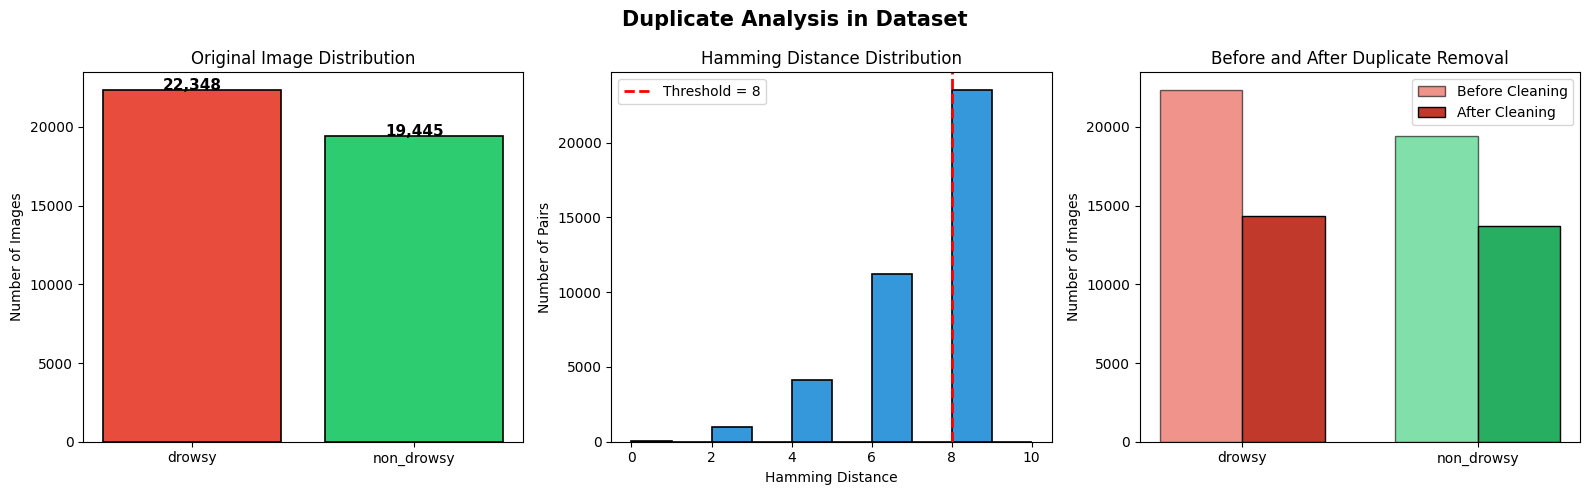

Plots saved as dedup_analysis.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Duplicate Analysis in Dataset', fontsize=15, fontweight='bold')

labels_count = df_all['label'].value_counts()

axes[0].bar(
    labels_count.index,
    labels_count.values,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    linewidth=1.2
)

axes[0].set_title('Original Image Distribution')
axes[0].set_ylabel('Number of Images')

for bar, val in zip(axes[0].patches, labels_count.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val:,}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

if len(df_pairs):
    axes[1].hist(
        df_pairs['distance'],
        bins=range(0, HASH_THRESHOLD + 3),
        color='#3498db',
        edgecolor='black',
        linewidth=1.2
    )

    axes[1].axvline(
        HASH_THRESHOLD,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Threshold = {HASH_THRESHOLD}'
    )

    axes[1].set_title('Hamming Distance Distribution')
    axes[1].set_xlabel('Hamming Distance')
    axes[1].set_ylabel('Number of Pairs')
    axes[1].legend()
else:
    axes[1].text(
        0.5,
        0.5,
        'No duplicate pairs found',
        ha='center',
        va='center',
        fontsize=12,
        transform=axes[1].transAxes,
        color='green'
    )
    axes[1].set_title('Hamming Distance Distribution')

df_clean = df_all[~df_all['path'].isin(to_remove)]
clean_counts = df_clean['label'].value_counts()

x = np.arange(len(labels_count.index))
w = 0.35

axes[2].bar(
    x - w / 2,
    labels_count.values,
    w,
    label='Before Cleaning',
    color=['#e74c3c', '#2ecc71'],
    alpha=0.6,
    edgecolor='black'
)

clean_vals = [clean_counts.get(l, 0) for l in labels_count.index]

axes[2].bar(
    x + w / 2,
    clean_vals,
    w,
    label='After Cleaning',
    color=['#c0392b', '#27ae60'],
    edgecolor='black'
)

axes[2].set_title('Before and After Duplicate Removal')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels_count.index)
axes[2].set_ylabel('Number of Images')
axes[2].legend()

plt.tight_layout()
plt.savefig('dedup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plots saved as dedup_analysis.png")

#### Display examples of detected duplicates

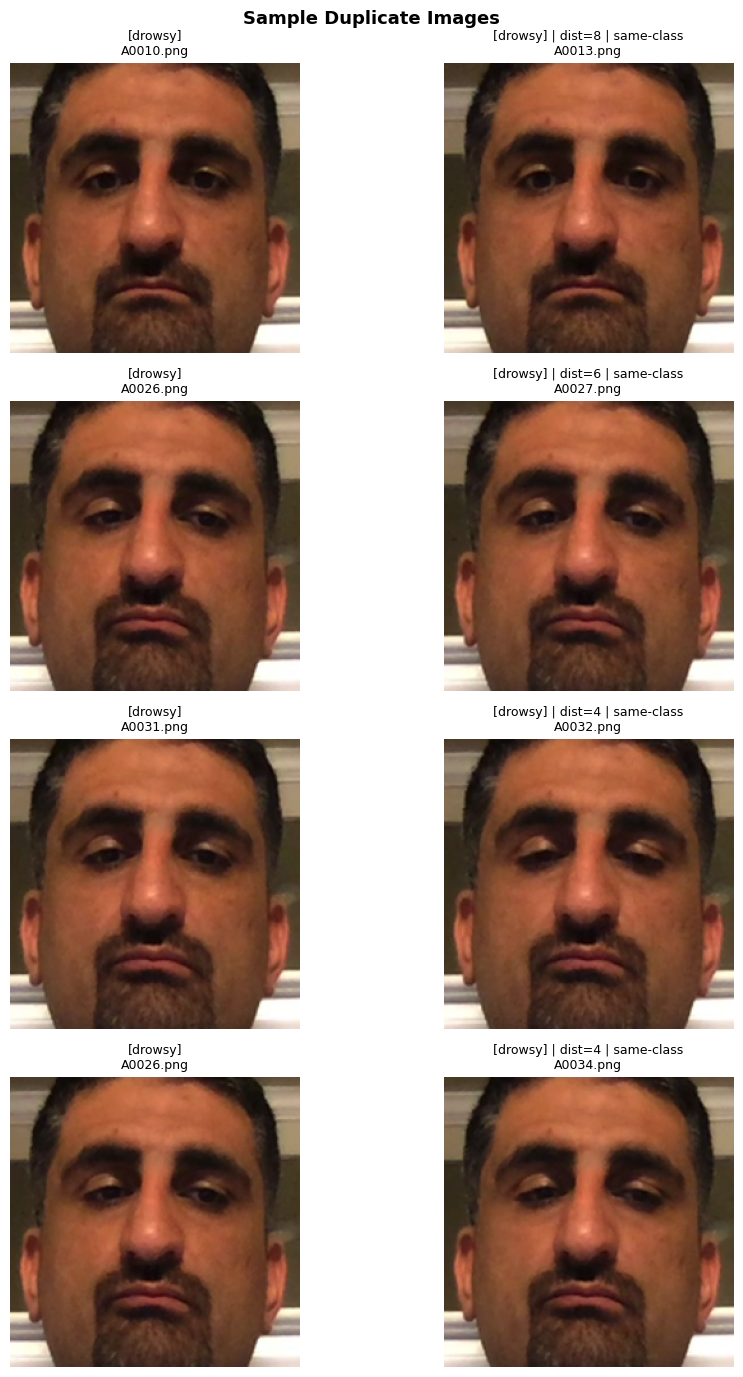

In [15]:
if len(df_pairs) > 0:
    samples = df_pairs.head(4)
    fig, axes = plt.subplots(len(samples), 2, figsize=(10, 3.5 * len(samples)))

    if len(samples) == 1:
        axes = [axes]

    for i, (_, row) in enumerate(samples.iterrows()):
        try:
            img_a = Image.open(row['path_a'])
            img_b = Image.open(row['path_b'])

            axes[i][0].imshow(img_a)
            axes[i][0].set_title(
                f"[{row['label_a']}]\n{Path(row['path_a']).name}",
                fontsize=9
            )

            axes[i][1].imshow(img_b)
            axes[i][1].set_title(
                f"[{row['label_b']}] | dist={row['distance']} | {row['type']}\n{Path(row['path_b']).name}",
                fontsize=9,
                color='red' if row['type'] == 'cross-class' else 'black'
            )

            for ax in axes[i]:
                ax.axis('off')

        except Exception as e:
            print(f"Error displaying image: {e}")

    plt.suptitle('Sample Duplicate Images', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('duplicate_samples.png', dpi=120, bbox_inches='tight')
    plt.show()

else:
    print("No duplicates found. Dataset is clean.")

#### Move duplicates to the `duplicates` folder

In [17]:
import shutil

print(f"About to move {len(to_remove):,} images to:")
print(f"{DUP_DIR}")
print("\nType 'yes' to continue:")
confirm = input()

if confirm.strip().lower() == 'yes':
    moved = 0
    failed = []

    for src_str in tqdm(to_remove, desc="Moving duplicates"):
        src = Path(src_str)

        try:
            rel = src.relative_to(BASE_DIR)
        except ValueError:
            rel = Path(src.name)

        dst = DUP_DIR / rel
        dst.parent.mkdir(parents=True, exist_ok=True)

        try:
            shutil.move(str(src), str(dst))
            moved += 1
        except Exception as e:
            failed.append({'path': src_str, 'error': str(e)})

    print(f"Successfully moved {moved:,} images")

    if failed:
        print(f"Failed to move {len(failed)} images")
        pd.DataFrame(failed).to_csv('move_errors.csv', index=False)

else:
    print("Cancelled. No changes were made.")

About to move 13,768 images to:
C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\duplicates

Type 'yes' to continue:


Moving duplicates: 100%|██████████| 13768/13768 [00:04<00:00, 3000.33it/s]

Successfully moved 13,768 images


#### Split the data 80/20


In [18]:
from sklearn.model_selection import train_test_split
from collections import Counter

remaining_drowsy = get_all_images(DROWSY_DIR)
remaining_ndrowsy = get_all_images(NDROWSY_DIR)

all_paths = [str(p) for p in remaining_drowsy + remaining_ndrowsy]
all_labels = ['drowsy'] * len(remaining_drowsy) + ['non_drowsy'] * len(remaining_ndrowsy)

print("Remaining images after cleaning:")
print(f"Drowsy: {len(remaining_drowsy):,}")
print(f"Non Drowsy: {len(remaining_ndrowsy):,}")
print(f"Total: {len(all_paths):,}")

X_train, X_test, y_train, y_test = train_test_split(
    all_paths,
    all_labels,
    test_size=TEST_RATIO,
    stratify=all_labels,
    random_state=RANDOM_SEED
)

print("\nSplit:")
print(f"Train: {len(X_train):,} ({len(X_train) / len(all_paths) * 100:.1f}%)")
print(f"Test: {len(X_test):,} ({len(X_test) / len(all_paths) * 100:.1f}%)")

print("\nTrain distribution:", dict(Counter(y_train)))
print("Test distribution:", dict(Counter(y_test)))

Remaining images after cleaning:
Drowsy: 14,323
Non Drowsy: 13,702
Total: 28,025

Split:
Train: 22,420 (80.0%)
Test: 5,605 (20.0%)

Train distribution: {'non_drowsy': 10962, 'drowsy': 11458}
Test distribution: {'non_drowsy': 2740, 'drowsy': 2865}


#### Copy files to `clean_dataset/train` and `clean_dataset/test`

In [19]:
def copy_split(paths, labels, split_name):

    copied = 0

    for src_str, label in tqdm(zip(paths, labels), total=len(paths),
                               desc=f"Copying {split_name}"):

        src = Path(src_str)
        dst = OUTPUT_DIR / split_name / label / src.name
        dst.parent.mkdir(parents=True, exist_ok=True)

        if dst.exists():
            dst = dst.with_stem(dst.stem + f"_{copied}")

        shutil.copy2(str(src), str(dst))
        copied += 1

    return copied


print("About to create clean_dataset and copy images.")
print("Type 'yes' to continue:")
confirm2 = input()

if confirm2.strip().lower() == 'yes':
    n_train = copy_split(X_train, y_train, 'train')
    n_test = copy_split(X_test, y_test, 'test')

    print("\nclean_dataset created:")
    print(f"train: {n_train:,} images")
    print(f"test: {n_test:,} images")

    print("\nFinal structure:")
    print("clean_dataset/")
    print(f"├── train/ (drowsy: {sum(l == 'drowsy' for l in y_train):,}, non_drowsy: {sum(l == 'non_drowsy' for l in y_train):,})")
    print(f"└── test/  (drowsy: {sum(l == 'drowsy' for l in y_test):,}, non_drowsy: {sum(l == 'non_drowsy' for l in y_test):,})")

else:
    print("Cancelled")

About to create clean_dataset and copy images.
Type 'yes' to continue:


Copying test: 100%|██████████| 5605/5605 [00:03<00:00, 1504.96it/s]


clean_dataset created:
train: 22,420 images
test: 5,605 images

Final structure:
clean_dataset/
├── train/ (drowsy: 11,458, non_drowsy: 10,962)
└── test/  (drowsy: 2,865, non_drowsy: 2,740)


#### Final Visual Report

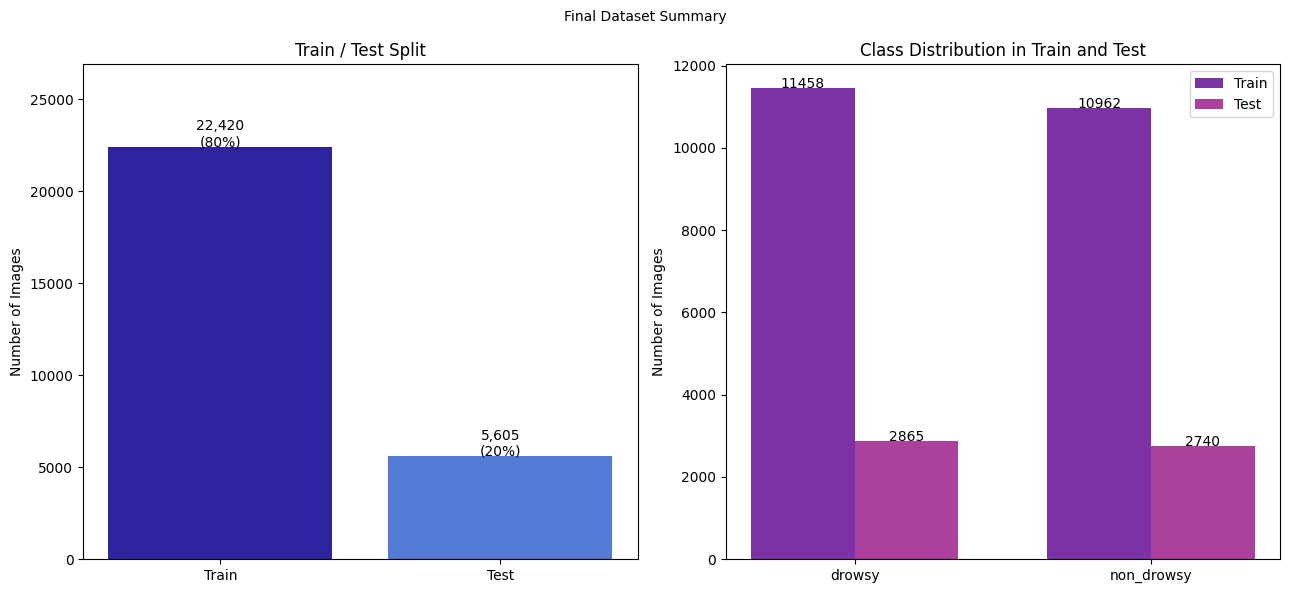

Complete Pipeline Summary
Original images: 41,793
Duplicates removed: 13,768
Clean images: 28,025
Train: 22,420 (80%)
Test: 5,605 (20%)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Final Dataset Summary', fontsize=10)

splits = ['Train', 'Test']
totals = [len(X_train), len(X_test)]
colors = ["#2f249f", "#537ad4"]

bars = axes[0].bar(splits, totals, color=colors)

for bar, val in zip(bars, totals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{val:,}\n({val / len(all_paths) * 100:.0f}%)',
        ha='center',
        fontsize=10
    )

axes[0].set_title('Train / Test Split')
axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, max(totals) * 1.2)

train_cnt = Counter(y_train)
test_cnt = Counter(y_test)

cats = ['drowsy', 'non_drowsy']
x = np.arange(len(cats))
w = 0.35

b1 = axes[1].bar(
    x - w / 2,
    [train_cnt[c] for c in cats],
    w,
    label='Train',
    color="#7c31a4"
)

b2 = axes[1].bar(
    x + w / 2,
    [test_cnt[c] for c in cats],
    w,
    label='Test',
    color="#ab419d"
)

for bar in list(b1) + list(b2):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(int(bar.get_height())),
        ha='center',
        fontsize=10
    )

axes[1].set_title('Class Distribution in Train and Test')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats)
axes[1].set_ylabel('Number of Images')
axes[1].legend()

plt.tight_layout()
plt.savefig('final_split_report.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("Complete Pipeline Summary")
print("=" * 60)
print(f"Original images: {len(df_all):,}")
print(f"Duplicates removed: {len(to_remove):,}")
print(f"Clean images: {len(all_paths):,}")
print(f"Train: {len(X_train):,} ({TRAIN_RATIO * 100:.0f}%)")
print(f"Test: {len(X_test):,} ({TEST_RATIO * 100:.0f}%)")
print("=" * 60)

#### Save Train/Test Lists as CSV

In [21]:
df_train = pd.DataFrame({'path': X_train, 'label': y_train, 'split': 'train'})
df_test  = pd.DataFrame({'path': X_test,  'label': y_test,  'split': 'test'})
df_split = pd.concat([df_train, df_test], ignore_index=True)

df_split.to_csv('dataset_split.csv', index=False)
df_pairs.to_csv('duplicates_report.csv', index=False) if len(df_pairs) else None

print("Files saved:")
print("   dataset_split.csv         — Train/Test list")
print("   duplicates_report.csv     — Duplicates report")
print("   dedup_analysis.png")
print("   final_split_report.png")
print("\nDataset is ready for training!")

Files saved:
   dataset_split.csv         — Train/Test list
   duplicates_report.csv     — Duplicates report
   dedup_analysis.png
   final_split_report.png

Dataset is ready for training!


## Save the full dataset for use in other files

In [22]:
import pandas as pd
from pathlib import Path

df_train = pd.DataFrame({
    'path': [str(Path(p).resolve()) for p in X_train],
    'label': y_train,
    'split': 'train'
})

df_test = pd.DataFrame({
    'path': [str(Path(p).resolve()) for p in X_test],
    'label': y_test,
    'split': 'test'
})

df_split = pd.concat([df_train, df_test], ignore_index=True)

SAVE_DIR = Path('saved_datasets')
SAVE_DIR.mkdir(exist_ok=True)

df_split.to_csv(SAVE_DIR / 'dataset_split.csv', index=False)
df_train.to_csv(SAVE_DIR / 'train.csv', index=False)
df_test.to_csv(SAVE_DIR / 'test.csv', index=False)

print('Files saved in:', SAVE_DIR.resolve())
print(f'dataset_split.csv: {len(df_split):,} rows')
print(f'train.csv: {len(df_train):,} rows')
print(f'test.csv: {len(df_test):,} rows')

print('\nSample from train.csv:')
print(df_train.head(3).to_string(index=False))

Files saved in: C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\saved_datasets
dataset_split.csv: 28,025 rows
train.csv: 22,420 rows
test.csv: 5,605 rows

Sample from train.csv:
                                                                                                                      path      label split
C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\Non Drowsy\x1105.png non_drowsy train
    C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\Drowsy\I1169.png     drowsy train
C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\Non Drowsy\w0524.png non_drowsy train


## Check that all images exist on disk

In [23]:
missing = [p for p in df_split['path'] if not Path(p).exists()]

if missing:
    print(f"{len(missing)} missing files")
    for p in missing[:10]:
        print(p)
else:
    print(f"All {len(df_split):,} files exist on disk and are ready to use")

All 28,025 files exist on disk and are ready to use
